[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sandeshjung/Machine-Learning-Foundation/blob/main/02_Supervised_classification/ensembles.ipynb)

In [1]:
# Colab setup: install the shared helpers (mlf_utils) and any extra packages. Does nothing when run locally.
import sys
if "google.colab" in sys.modules:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/sandeshjung/Machine-Learning-Foundation.git")

# Ensemble Methods: Bagging, Random Forests & Boosting

A single deep decision tree has **low bias but high variance**: small changes in the data produce a very different tree. Ensembles combine many models to fix that:

- **Bagging / random forests** train many deep trees *independently* on bootstrap samples and **average** them, which reduces variance.
- **Boosting** trains many shallow trees *sequentially*, each one correcting the errors of the ensemble so far, which reduces bias.

Theory: [Ensemble Methods](README.md#6-ensembles-bagging-random-forests-and-boosting)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, RandomForestClassifier)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from mlf_utils import check_agreement, check_close, plot_decision_regions

sns.set_theme(style="whitegrid")
np.random.seed(42)

### Why averaging helps
If $B$ models each have variance $\sigma^2$ and pairwise correlation $\rho$, their average has variance

$$\large \text{Var}\Big(\frac{1}{B}\sum_{b=1}^{B} f_b\Big) = \rho\,\sigma^2 + \frac{1 - \rho}{B}\,\sigma^2$$

More models shrink the second term, but the first term stays. Averaging therefore only helps as much as the models **disagree**. Random forests exist to push $\rho$ down.

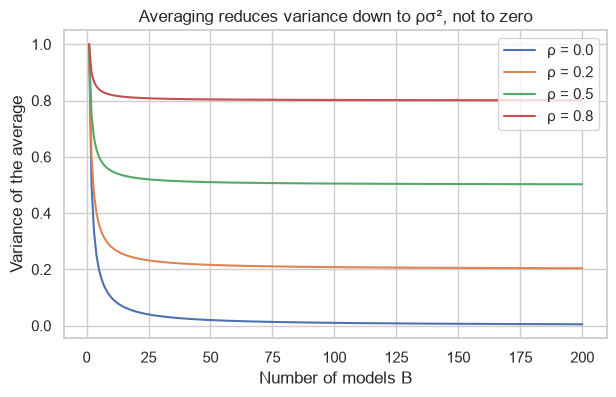

In [3]:
sigma2, B = 1.0, np.arange(1, 201)
plt.figure(figsize=(7, 4))
for rho in [0.0, 0.2, 0.5, 0.8]:
    plt.plot(B, rho * sigma2 + (1 - rho) * sigma2 / B, label=f"ρ = {rho}")
plt.xlabel("Number of models B"); plt.ylabel("Variance of the average"); plt.legend()
plt.title("Averaging reduces variance down to ρσ², not to zero")
plt.show()

### Data
Noisy moons: a single tree overfits them badly. Float32, as scikit-learn trees use internally.

In [4]:
X, y = make_moons(n_samples=1000, noise=0.35, random_state=42)
X = X.astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

single_tree = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
print(f"Single unpruned tree: train acc = {single_tree.score(X_train, y_train):.3f}, test acc = {single_tree.score(X_test, y_test):.3f}")

Single unpruned tree: train acc = 1.000, test acc = 0.837


## Bagging and Random Forests from scratch
**Bagging** (bootstrap aggregating): draw $n$ samples **with replacement** for each tree, train an unpruned tree on it, and average the trees' predicted probabilities.

**Random forest** = bagging + a random subset of $\sqrt{d}$ features considered **at every split** (`max_features="sqrt"`). The trees become less alike (smaller $\rho$), so the average improves.

**Out-of-bag (OOB) estimate:** each bootstrap sample leaves out about $(1 - 1/n)^n \approx 36.8\%$ of the data. Scoring each training point using only the trees that *didn't* see it gives a free validation estimate, with no hold-out set needed.

In [5]:
class ScratchBaggedTrees:
    def __init__(self, n_estimators=100, max_features=None, random_state=0):
        self.n_estimators, self.max_features, self.random_state = n_estimators, max_features, random_state

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n = len(y)
        self.n_classes_ = int(y.max()) + 1
        self.trees_, self.oob_masks_ = [], []
        for _ in range(self.n_estimators):
            idx = rng.randint(0, n, n)                          # bootstrap: n draws with replacement
            tree = DecisionTreeClassifier(max_features=self.max_features, random_state=rng.randint(2**31 - 1))
            tree.fit(X[idx], y[idx])
            oob = np.ones(n, dtype=bool); oob[idx] = False      # samples this tree never saw
            self.trees_.append(tree); self.oob_masks_.append(oob)

        # OOB score: for each sample, average only the trees for which it was out-of-bag
        votes = np.zeros((n, self.n_classes_)); counts = np.zeros(n)
        for tree, oob in zip(self.trees_, self.oob_masks_):
            votes[oob] += tree.predict_proba(X[oob]); counts[oob] += 1
        seen = counts > 0
        self.oob_score_ = np.mean(votes[seen].argmax(axis=1) == y[seen])
        return self

    def predict_proba(self, X, n_trees=None):
        trees = self.trees_[:n_trees] if n_trees else self.trees_
        return np.mean([t.predict_proba(X) for t in trees], axis=0)

    def predict(self, X, n_trees=None):
        return self.predict_proba(X, n_trees).argmax(axis=1)

In [6]:
bagging = ScratchBaggedTrees(n_estimators=200, max_features=None).fit(X_train, y_train)
forest = ScratchBaggedTrees(n_estimators=200, max_features="sqrt").fit(X_train, y_train)
for name, m in [("Bagging", bagging), ("Random forest", forest)]:
    print(f"{name:14s} test acc = {np.mean(m.predict(X_test) == y_test):.3f}   OOB estimate = {m.oob_score_:.3f}")

Bagging        test acc = 0.880   OOB estimate = 0.873
Random forest  test acc = 0.880   OOB estimate = 0.879


### Verifying against scikit-learn
`RandomForestClassifier` uses a different random number stream, so individual trees differ, but with 200 trees the two forests should make almost the same predictions and have similar accuracy and OOB estimates. *(With only 2 features, $\sqrt{2}$ rounds to 1 feature per split, so here the "random forest" picks a random feature at every split.)*

In [7]:
sk_forest = RandomForestClassifier(n_estimators=200, max_features="sqrt", oob_score=True, random_state=0).fit(X_train, y_train)
check_agreement("Random forest test predictions vs sklearn", forest.predict(X_test), sk_forest.predict(X_test), min_agreement=0.95)
check_close("Random forest test accuracy vs sklearn", np.mean(forest.predict(X_test) == y_test), sk_forest.score(X_test, y_test), atol=0.03)
check_close("OOB estimate vs sklearn", forest.oob_score_, sk_forest.oob_score_, atol=0.03)

✓ Random forest test predictions vs sklearn: 98.7% agreement


✓ Random forest test accuracy vs sklearn: matches (max |diff| = 0.00e+00)
✓ OOB estimate vs sklearn: matches (max |diff| = 5.71e-03)


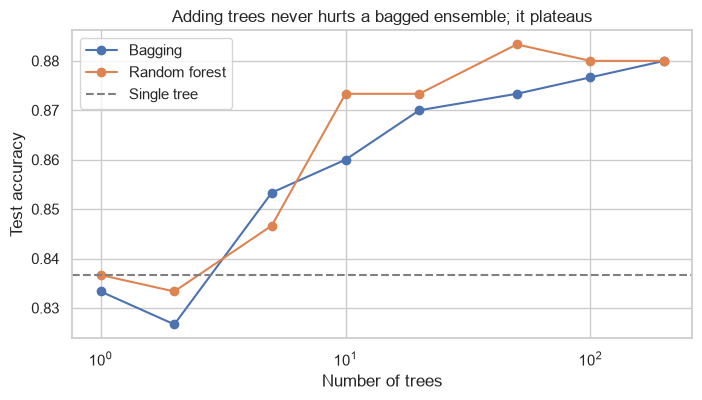

In [8]:
n_range = [1, 2, 5, 10, 20, 50, 100, 200]
plt.figure(figsize=(8, 4))
for name, m in [("Bagging", bagging), ("Random forest", forest)]:
    plt.plot(n_range, [np.mean(m.predict(X_test, n) == y_test) for n in n_range], "o-", label=name)
plt.axhline(single_tree.score(X_test, y_test), color="gray", ls="--", label="Single tree")
plt.xscale("log"); plt.xlabel("Number of trees"); plt.ylabel("Test accuracy"); plt.legend()
plt.title("Adding trees never hurts a bagged ensemble; it plateaus")
plt.show()

## AdaBoost from scratch
AdaBoost fits a sequence of **weak learners** (here decision *stumps*: depth-1 trees), each on a **reweighted** training set that emphasises the samples the previous learners got wrong. With $K$ classes (the SAMME algorithm):

1. Start with uniform weights $w_i = 1/n$.
2. For $m = 1, \dots, M$:
   - fit a stump $h_m$ with sample weights $w$
   - weighted error: $\varepsilon_m = \sum_i w_i \mathbb{1}[h_m(x_i) \ne y_i] \,/\, \sum_i w_i$
   - learner weight: $\alpha_m = \eta\left(\log\frac{1 - \varepsilon_m}{\varepsilon_m} + \log(K - 1)\right)$
   - increase the weights of misclassified samples: $w_i \leftarrow w_i \, e^{\alpha_m \mathbb{1}[h_m(x_i) \ne y_i]}$, then renormalise
3. Predict $\arg\max_k \sum_m \alpha_m \mathbb{1}[h_m(x) = k]$.

In [9]:
class ScratchAdaBoost:
    def __init__(self, n_estimators=50, learning_rate=1.0):
        self.n_estimators, self.learning_rate = n_estimators, learning_rate

    def fit(self, X, y):
        n = len(y)
        self.classes_ = np.unique(y); K = len(self.classes_)
        w = np.full(n, 1.0 / n)
        self.stumps_, self.alphas_, self.errors_ = [], [], []
        for _ in range(self.n_estimators):
            stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X, y, sample_weight=w)
            miss = stump.predict(X) != y
            err = np.sum(w[miss]) / np.sum(w)
            if err <= 0:                                     # perfect learner: keep it and stop
                self.stumps_.append(stump); self.alphas_.append(1.0); self.errors_.append(0.0)
                break
            alpha = self.learning_rate * (np.log((1 - err) / err) + np.log(K - 1))
            w = w * np.exp(alpha * miss)
            w /= w.sum()
            self.stumps_.append(stump); self.alphas_.append(alpha); self.errors_.append(err)
        return self

    def decision_scores(self, X, n_estimators=None):
        scores = np.zeros((len(X), len(self.classes_)))
        for stump, alpha in list(zip(self.stumps_, self.alphas_))[:n_estimators]:
            scores[np.arange(len(X)), np.searchsorted(self.classes_, stump.predict(X))] += alpha
        return scores

    def predict(self, X, n_estimators=None):
        return self.classes_[self.decision_scores(X, n_estimators).argmax(axis=1)]

AdaBoost (200 stumps) test acc = 0.873


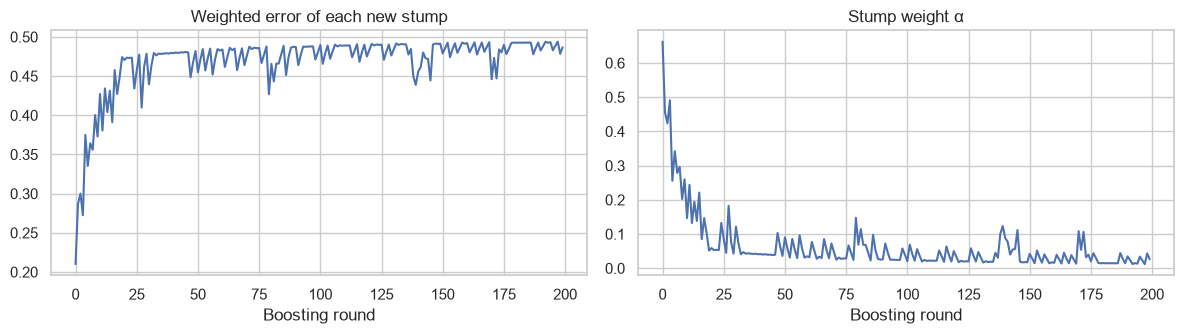

In [10]:
ada = ScratchAdaBoost(n_estimators=200, learning_rate=0.5).fit(X_train, y_train)
print(f"AdaBoost (200 stumps) test acc = {np.mean(ada.predict(X_test) == y_test):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(ada.errors_); axes[0].set_title("Weighted error of each new stump"); axes[0].set_xlabel("Boosting round")
axes[1].plot(ada.alphas_); axes[1].set_title("Stump weight α"); axes[1].set_xlabel("Boosting round")
plt.tight_layout(); plt.show()

Each stump's weighted error creeps towards 0.5: later stumps are trained on the hard, reweighted samples, where barely beating chance is all a single split can do.

### Verifying against scikit-learn
`AdaBoostClassifier` with the same stumps implements the same SAMME updates, so the per-round errors, learner weights and predictions should match.

In [11]:
sk_ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=200,
                            learning_rate=0.5, random_state=0).fit(X_train, y_train)
check_close("AdaBoost per-round weighted errors vs sklearn", ada.errors_, sk_ada.estimator_errors_, atol=1e-6)
check_close("AdaBoost learner weights vs sklearn", ada.alphas_, sk_ada.estimator_weights_, atol=1e-5)
check_agreement("AdaBoost test predictions vs sklearn", ada.predict(X_test), sk_ada.predict(X_test), min_agreement=1.0)

✓ AdaBoost per-round weighted errors vs sklearn: matches (max |diff| = 3.33e-16)
✓ AdaBoost learner weights vs sklearn: matches (max |diff| = 7.55e-16)
✓ AdaBoost test predictions vs sklearn: 100.0% agreement


## Gradient Boosting from scratch
Gradient boosting builds an additive model $F_M(x) = F_0 + \eta \sum_{m=1}^{M} h_m(x)$ by **gradient descent in function space**. Each new tree $h_m$ is fit to the *negative gradient* of the loss with respect to the current predictions:

$$\large r_i^{(m)} = -\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \Bigg|_{F = F_{m-1}}$$

For squared error $L = \frac{1}{2}(y - F)^2$ the negative gradient is simply the **residual** $y - F$, so each tree learns "what the ensemble still gets wrong". The learning rate $\eta$ (shrinkage) scales each step down: smaller $\eta$ needs more trees but generalises better. For classification the same recipe uses the log-loss, whose negative gradient is $y - p$.

In [12]:
class ScratchGradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators, self.learning_rate, self.max_depth = n_estimators, learning_rate, max_depth

    def fit(self, X, y):
        self.init_ = y.mean()                                  # F_0: the best constant under squared error
        F = np.full(len(y), self.init_)
        self.trees_ = []
        for _ in range(self.n_estimators):
            residuals = y - F                                  # negative gradient of 1/2 (y - F)^2
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=0).fit(X, residuals)
            F += self.learning_rate * tree.predict(X)
            self.trees_.append(tree)
        return self

    def predict(self, X, n_estimators=None):
        F = np.full(len(X), self.init_)
        for tree in self.trees_[:n_estimators]:
            F += self.learning_rate * tree.predict(X)
        return F

In [13]:
rng = np.random.RandomState(0)
x_reg = np.sort(rng.uniform(0, 6, 300)).reshape(-1, 1).astype(np.float32)
y_reg = np.sin(x_reg).ravel() + 0.3 * np.cos(4 * x_reg).ravel() + rng.normal(0, 0.25, 300)
xr_train, xr_test, yr_train, yr_test = train_test_split(x_reg, y_reg, test_size=0.3, random_state=42)

gbr = ScratchGradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3).fit(xr_train, yr_train)
mse = lambda a, b: np.mean((a - b) ** 2)
print(f"Scratch gradient boosting: test MSE = {mse(gbr.predict(xr_test), yr_test):.4f}")

Scratch gradient boosting: test MSE = 0.1057


### Verifying against scikit-learn
With squared error and no subsampling, `GradientBoostingRegressor` runs exactly this algorithm, so predictions should agree to floating-point precision **at every stage**.

In [14]:
sk_gbr = GradientBoostingRegressor(loss="squared_error", n_estimators=200, learning_rate=0.1, max_depth=3,
                                   random_state=0).fit(xr_train, yr_train)
check_close("Gradient boosting test predictions vs sklearn", gbr.predict(xr_test), sk_gbr.predict(xr_test), atol=1e-6)
staged = list(sk_gbr.staged_predict(xr_test))
check_close("Predictions after 10 / 50 / 200 trees vs sklearn",
            [gbr.predict(xr_test, n) for n in (10, 50, 200)], [staged[9], staged[49], staged[199]], atol=1e-6)

✓ Gradient boosting test predictions vs sklearn: matches (max |diff| = 2.22e-16)
✓ Predictions after 10 / 50 / 200 trees vs sklearn: matches (max |diff| = 2.22e-16)


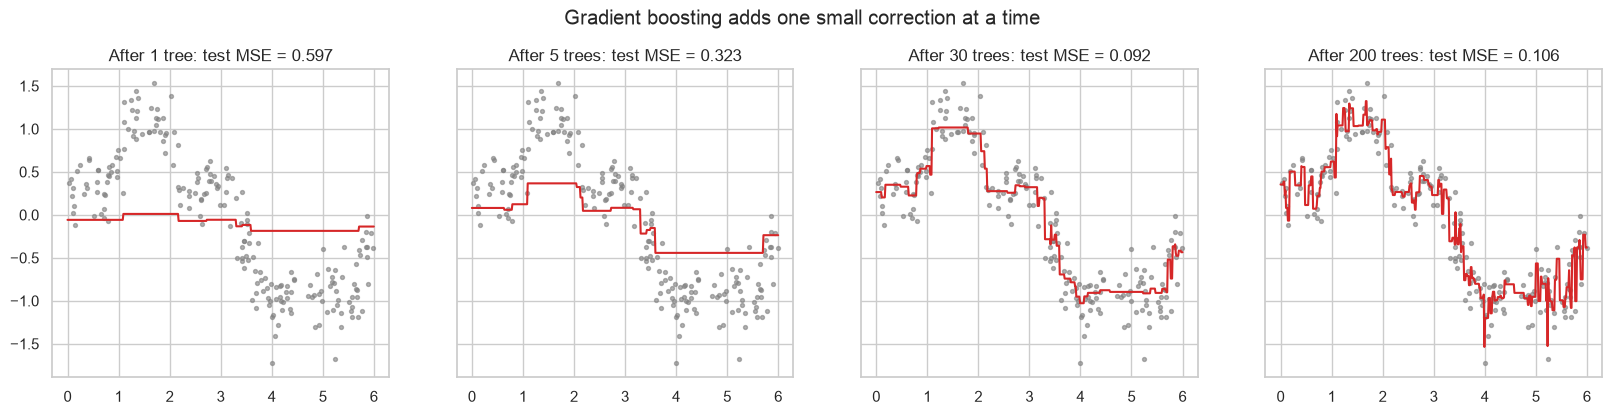

In [15]:
x_grid = np.linspace(0, 6, 500).reshape(-1, 1).astype(np.float32)
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, n in zip(axes, [1, 5, 30, 200]):
    ax.scatter(xr_train, yr_train, s=8, color="gray", alpha=0.6)
    ax.plot(x_grid, gbr.predict(x_grid, n), color="tab:red")
    ax.set_title(f"After {n} tree{'s' if n > 1 else ''}: test MSE = {mse(gbr.predict(xr_test, n), yr_test):.3f}")
plt.suptitle("Gradient boosting adds one small correction at a time", y=1.03)
plt.show()

### Try it: boosting rounds and learning rate
With a large learning rate the model fits quickly and soon starts chasing noise. With a small one it needs many more trees but ends up smoother. The right panel shows the train and test error across rounds: the gap is overfitting, and **early stopping** means picking the round where the test (validation) error is lowest.

*Interactive: run the notebook locally or in Colab to use the controls. GitHub only renders a static page.*

In [16]:
from ipywidgets import FloatLogSlider, IntSlider, interact

@interact(n_estimators=IntSlider(value=100, min=1, max=500, step=1, continuous_update=False),
          learning_rate=FloatLogSlider(value=0.1, base=10, min=-2, max=0, step=0.1, continuous_update=False),
          max_depth=IntSlider(value=3, min=1, max=8, continuous_update=False))
def explore_boosting(n_estimators, learning_rate, max_depth):
    model = ScratchGradientBoostingRegressor(n_estimators, learning_rate, max_depth).fit(xr_train, yr_train)
    rounds = np.arange(1, n_estimators + 1)
    train_curve = [mse(model.predict(xr_train, n), yr_train) for n in rounds]
    test_curve = [mse(model.predict(xr_test, n), yr_test) for n in rounds]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].scatter(xr_train, yr_train, s=8, color="gray", alpha=0.6)
    axes[0].plot(x_grid, model.predict(x_grid), color="tab:red")
    axes[0].set_title(f"{n_estimators} trees, lr = {learning_rate:.2g}, depth {max_depth}")
    axes[1].plot(rounds, train_curve, label="Train MSE"); axes[1].plot(rounds, test_curve, label="Test MSE")
    best = int(np.argmin(test_curve)) + 1
    axes[1].axvline(best, color="gray", ls="--", label=f"best round = {best}")
    axes[1].set_xlabel("Boosting round"); axes[1].set_yscale("log"); axes[1].legend()
    plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=100, continuous_update=False, description='n_estimators', max=500, min=1…

## Comparing all the methods
`HistGradientBoostingClassifier` is scikit-learn's fast, LightGBM-style implementation. It bins features into histograms, grows trees on the bins and supports missing values natively. It's the go-to choice for tabular data of any real size.

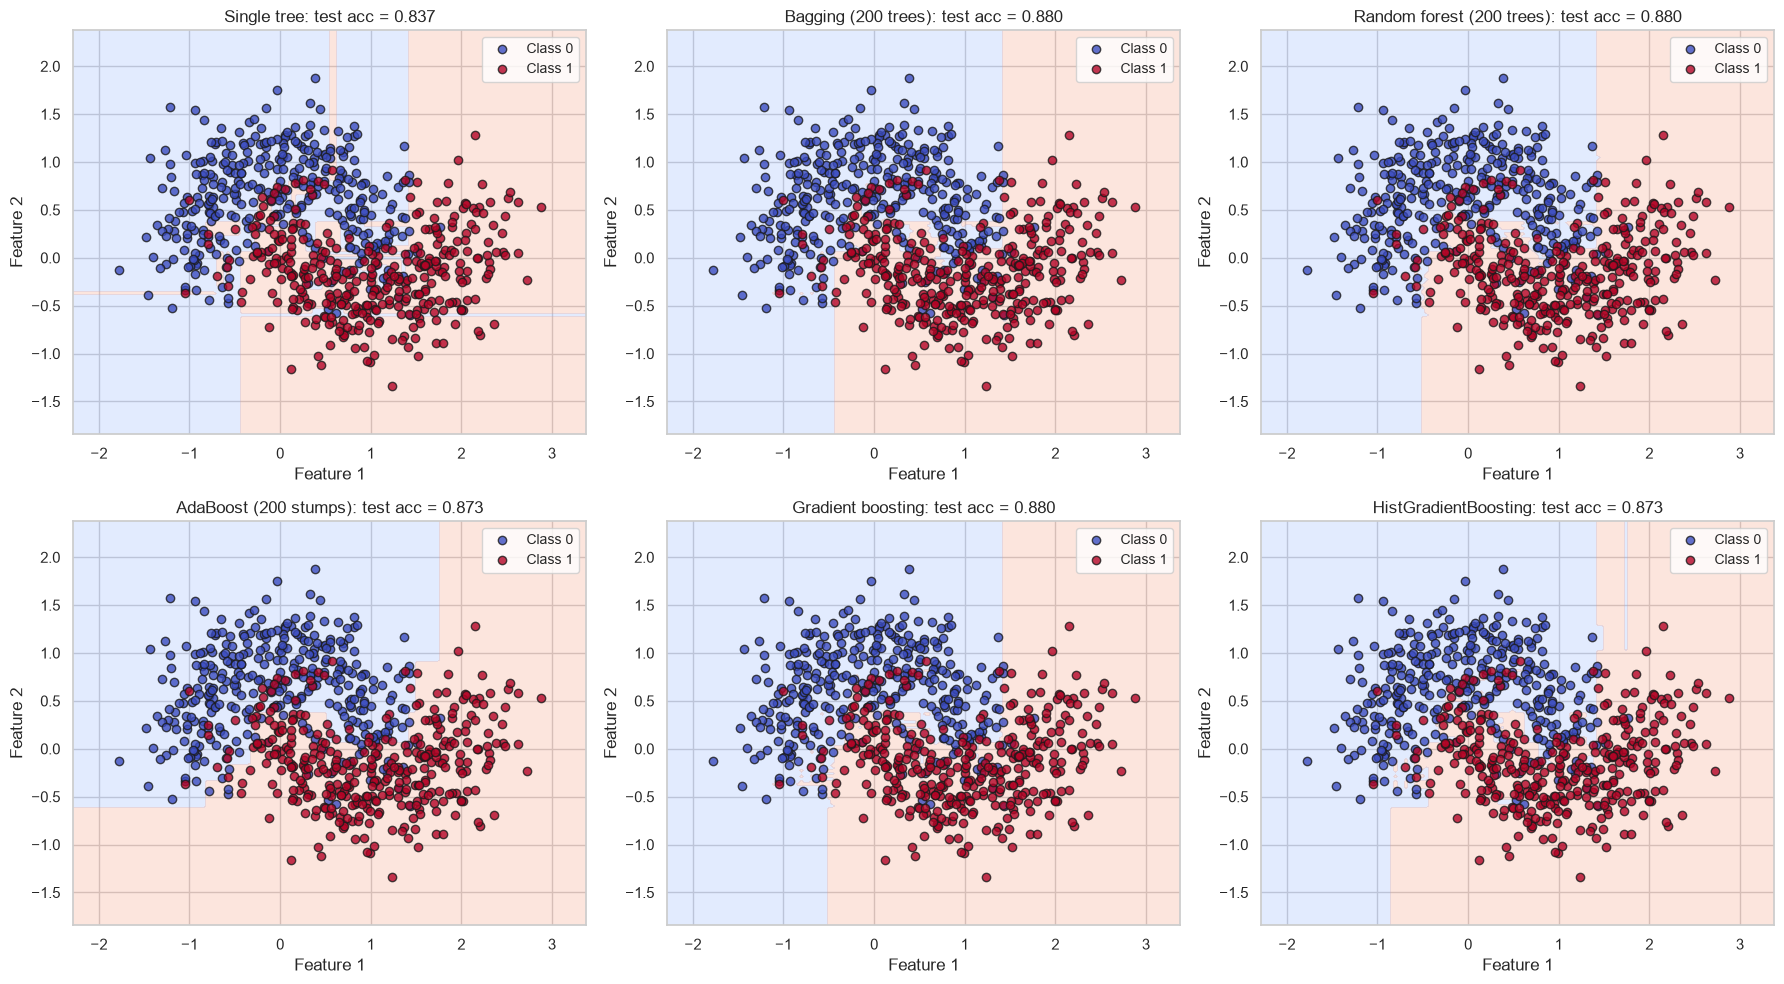

,train acc,test acc
model,,
Single tree,1.000,0.837
Bagging (200 trees),1.000,0.880
Random forest (200 trees),1.000,0.880
AdaBoost (200 stumps),0.897,0.873
Gradient boosting,0.977,0.880
HistGradientBoosting,0.983,0.873


In [17]:
models = {
    "Single tree": single_tree,
    "Bagging (200 trees)": bagging,
    "Random forest (200 trees)": forest,
    "AdaBoost (200 stumps)": ada,
    "Gradient boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=0).fit(X_train, y_train),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0).fit(X_train, y_train),
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
rows = []
for ax, (name, m) in zip(axes.ravel(), models.items()):
    train_acc, test_acc = np.mean(m.predict(X_train) == y_train), np.mean(m.predict(X_test) == y_test)
    rows.append({"model": name, "train acc": train_acc, "test acc": test_acc})
    plot_decision_regions(m.predict, X_train, y_train, ax=ax, resolution=150, title=f"{name}: test acc = {test_acc:.3f}")
plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("model").round(3)

### Summary
| | Bagging / Random forest | Boosting (AdaBoost, gradient boosting) |
|---|---|---|
| Trees are trained | Independently (parallel) | Sequentially, each correcting the last |
| Base trees | Deep (low bias, high variance) | Shallow (high bias, low variance) |
| Mainly reduces | Variance | Bias (and variance, with shrinkage) |
| Overfits with more trees? | No, it plateaus | Yes: tune `n_estimators` with early stopping |
| Key hyperparameters | `n_estimators`, `max_features`, `min_samples_leaf` | `learning_rate`, `n_estimators`, `max_depth`, `subsample` |
| Bonus | Free OOB validation estimate | Usually the most accurate choice on tabular data |

**XGBoost, LightGBM and CatBoost** are industrial gradient-boosting libraries. They add a second-order (Newton) step using the Hessian of the loss, explicit L1/L2 penalties on leaf values, histogram-based split finding, and smart handling of missing values and categorical features. The ideas are exactly the ones implemented above.